In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (5.0, 4.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

In [2]:
def load_mnist_images(filename):
    with open(filename, 'rb') as f:
        # Skip the header information (first 16 bytes)
        f.read(16)

        # Read the image data
        buffer = f.read()
        images = np.frombuffer(buffer, dtype=np.uint8)

        # The original images are 28x28, so reshape them to (60000, 28*28)
        images = images.reshape(-1, 28 * 28)

        # Transpose to get the shape (784, 60000)
        images = images.T

        return images



# File path to the MNIST training set images
train_images_path = 'data/MNIST/raw/train-images-idx3-ubyte'

test_images_path = 'data/MNIST/raw/t10k-images-idx3-ubyte'


# Load the MNIST images and reshape them to (784, m)
mnist_train_images = load_mnist_images(train_images_path)
mnist_test_images = load_mnist_images(test_images_path)


# Verify the shape
print(mnist_train_images.shape)  # Output should be (784, 60000)
print(mnist_test_images.shape)  # Output should be (784, 10000)

(784, 60000)
(784, 10000)


In [3]:
def load_mnist_labels(filename):
    with open(filename, 'rb') as f:
        # Skip the header information (first 16 bytes)
        f.read(8)

        # Read the image data
        buffer = f.read()
        images = np.frombuffer(buffer, dtype=np.uint8)

        return images

# File path to the MNIST labels
train_labels_path = 'data/MNIST/raw/train-labels-idx1-ubyte'
test_labels_path = 'data/MNIST/raw/t10k-labels-idx1-ubyte'

# Load the MNIST labels and reshape them to (1, m)
mnist_train_labels = load_mnist_labels(train_labels_path)
mnist_test_labels = load_mnist_labels(test_labels_path)

# Verify the shape
print(mnist_train_labels.shape)  # Output should be (60000,)
print(mnist_test_labels.shape)  # Output should be (10000,)

(60000,)
(10000,)


In [4]:
# Take in an array with classes from 0, 1, ... n, with m number of elements
# Returns a one hot encoded matrix of shape (n, m)
def one_hot_array(Y):
    b = np.zeros((Y.size, Y.max() + 1))
    b[np.arange(Y.size), Y] = 1
    return b.T

mnist_train_labels = one_hot_array(mnist_train_labels)
mnist_test_labels = one_hot_array(mnist_test_labels)

print(mnist_train_labels.shape)
print(mnist_test_labels.shape)

(10, 60000)
(10, 10000)


In [5]:
X_train = mnist_train_images[:, 0:10000]
X_test = mnist_test_images[:, 0:5000]
Y_train = mnist_train_labels[:, 0:10000]
Y_test = mnist_test_labels[:, 0:5000]

print("Shape of X_train is: " + str(X_train.shape))
print("Shape of X_test is: " + str(X_test.shape))
print("Shape of Y_train is: " + str(Y_train.shape))
print("Shape of Y_test is: " + str(Y_test.shape))

Shape of X_train is: (784, 10000)
Shape of X_test is: (784, 5000)
Shape of Y_train is: (10, 10000)
Shape of Y_test is: (10, 5000)


In [6]:
#######################################################################GPT#START###########################################################

In [7]:
def relu(Z):
    return np.maximum(0, Z)

In [8]:
# Derivative of ReLU
def relu_derivative(Z):
    return Z>0

In [9]:
# Softmax activation function
def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return expZ / expZ.sum(axis=0, keepdims=True)

In [10]:
# Initialize parameters
def initialize_parameters(layer_sizes):
    parameters = {}
    L = len(layer_sizes)
    for l in range(1, L):
        parameters['W' + str(l)] = np.random.randn(layer_sizes[l], layer_sizes[l-1]) * 0.01
        parameters['b' + str(l)] = np.zeros((layer_sizes[l], 1))
    return parameters

In [11]:
# Forward propagation
def forward_propagation(X, parameters):
    cache = {'A0': X}
    L = len(parameters) // 2
    A_prev = X
    for l in range(1, L + 1):
        W = parameters['W' + str(l)]
        b = parameters['b' + str(l)]
        Z = np.dot(W, A_prev) + b
        if l == L:
            A = softmax(Z)
        else:
            A = relu(Z)
        cache['Z' + str(l)] = Z
        cache['A' + str(l)] = A
        A_prev = A
    return A, cache

In [12]:
# Compute cost
def compute_cost(AL, Y):
    m = Y.shape[1]
    cost = -np.sum(Y * np.log(AL+ 1e-8)) / m
    return cost

In [13]:
# Backward propagation
def backward_propagation(parameters, cache, X, Y):
    grads = {}
    L = len(parameters) // 2
    m = X.shape[1]
    Y = Y.reshape(cache['A' + str(L)].shape)
    dZL = cache['A' + str(L)] - Y
    for l in reversed(range(1, L + 1)):
        #This first line is interesting, it skips storing dA[l-1], and saves a shit load of time. Note that A[l-1]=W[l]^T*dZ[l]  =>  A[l]=W[l+1]^T*dZ[l+1]
        #I guess making new vars means calls to RAM which is hela slow
        dZ = dZL if l == L else np.dot(parameters['W' + str(l+1)].T, dZL) * relu_derivative(cache['Z' + str(l)])
        dW = np.dot(dZ, cache['A' + str(l-1)].T) / m
        db = np.sum(dZ, axis=1, keepdims=True) / m
        grads['dW' + str(l)] = dW
        grads['db' + str(l)] = db
        dZL = dZ
    return grads

In [14]:
# Update parameters
def update_parameters(parameters, grads, learning_rate):
    L = len(parameters) // 2
    for l in range(1, L + 1):
        parameters['W' + str(l)] -= learning_rate * grads['dW' + str(l)]
        parameters['b' + str(l)] -= learning_rate * grads['db' + str(l)]
    return parameters

In [15]:
def update_parameters_model2(parameters_1, parameters_2, grads_1, learning_rate, alpha):
    L = len(parameters_1) // 2  # Number of layers in the neural network

    for l in range(1, L + 1):
        # Compute the penalty gradient based on params2 (which is constant)
        W_diff = parameters_1['W' + str(l)] - parameters_2['W' + str(l)]
        penalty_gradient = alpha * W_diff / (np.linalg.norm(W_diff) ** 3)

        # Update parameters for Theta_1
        parameters_1['W' + str(l)] -= learning_rate * (grads_1['dW' + str(l)] + penalty_gradient)
        parameters_1['b' + str(l)] -= learning_rate * grads_1['db' + str(l)]

    return parameters_1

In [16]:
# Model training
def model(X, Y, layer_sizes, learning_rate=0.01, num_iterations=1000):
    parameters = initialize_parameters(layer_sizes)
    costs = []
    x_costs = []
    for i in range(num_iterations):
        AL, cache = forward_propagation(X, parameters)
        cost = compute_cost(AL, Y)
        grads = backward_propagation(parameters, cache, X, Y)
        parameters = update_parameters(parameters, grads, learning_rate)
        if i % 10 == 0:
            costs.append(cost)
            x_costs.append(i)
            if i % 100 == 0:
                #print(f"Cost after iteration {i}: {cost}")
                predictionsTr = predict(X_train, parameters)
                accuracyTr = np.mean(predictionsTr == np.argmax(Y_train, axis=0))
                #print(f"Training accuracy: {accuracy * 100:.2f}%")

                predictionsTe = predict(X_test, parameters)
                accuracyTe = np.mean(predictionsTe == np.argmax(Y_test, axis=0))
                #print(f"Test accuracy: {accuracy * 100:.2f}%")

                print(f"Cost after iteration {i}: {cost}", f" Training accuracy: {accuracyTr * 100:.2f}%", f"Test accuracy: {accuracyTe * 100:.2f}%", f"Difference: {(accuracyTr-accuracyTe)*100:.2f}")


    # plot the cost
    plt.plot(x_costs, np.squeeze(costs))
    plt.ylabel('Cost')
    plt.xlabel('Iterations')
    plt.title("Learning rate =" + str(learning_rate))
    plt.show()
    return parameters

In [17]:
# Model training
def model2(X, Y, layer_sizes, parameters_2 = None, learning_rate=0.01, num_iterations=1000):
    parameters = initialize_parameters(layer_sizes)
    costs = []
    x_costs = []
    for i in range(num_iterations):
        AL, cache = forward_propagation(X, parameters)
        cost = compute_cost(AL, Y)
        grads = backward_propagation(parameters, cache, X, Y)
        parameters = update_parameters_model2(parameters_1 = parameters, parameters_2 = parameters_2, grads_1 = grads, learning_rate = learning_rate, alpha = .01)
        if i % 10 == 0:
            costs.append(cost)
            x_costs.append(i)
            if i % 100 == 0:
                #print(f"Cost after iteration {i}: {cost}")
                predictionsTr = predict(X_train, parameters)
                accuracyTr = np.mean(predictionsTr == np.argmax(Y_train, axis=0))
                #print(f"Training accuracy: {accuracy * 100:.2f}%")

                predictionsTe = predict(X_test, parameters)
                accuracyTe = np.mean(predictionsTe == np.argmax(Y_test, axis=0))
                #print(f"Test accuracy: {accuracy * 100:.2f}%")

                print(f"Cost after iteration {i}: {cost}", f" Training accuracy: {accuracyTr * 100:.2f}%", f"Test accuracy: {accuracyTe * 100:.2f}%", f"Difference: {(accuracyTr-accuracyTe)*100:.2f}")


    # plot the cost
    plt.plot(x_costs, np.squeeze(costs))
    plt.ylabel('Cost')
    plt.xlabel('Iterations')
    plt.title("Learning rate =" + str(learning_rate))
    plt.show()
    return parameters

In [18]:
# Predict function
def predict(X, parameters):
    AL, _ = forward_propagation(X, parameters)
    return np.argmax(AL, axis=0)


Cost after iteration 0: 2.315073052973188  Training accuracy: 14.45% Test accuracy: 15.36% Difference: -0.91
Cost after iteration 100: 0.2588545289657555  Training accuracy: 92.68% Test accuracy: 88.74% Difference: 3.94
Cost after iteration 200: 0.20283059992727454  Training accuracy: 93.05% Test accuracy: 88.54% Difference: 4.51
Cost after iteration 300: 0.10408724504334038  Training accuracy: 97.22% Test accuracy: 92.34% Difference: 4.88
Cost after iteration 400: 0.07144274478553161  Training accuracy: 98.33% Test accuracy: 92.62% Difference: 5.71
Cost after iteration 500: 0.04981158117711368  Training accuracy: 99.14% Test accuracy: 92.88% Difference: 6.26
Cost after iteration 600: 0.03505352017084491  Training accuracy: 99.43% Test accuracy: 93.08% Difference: 6.35


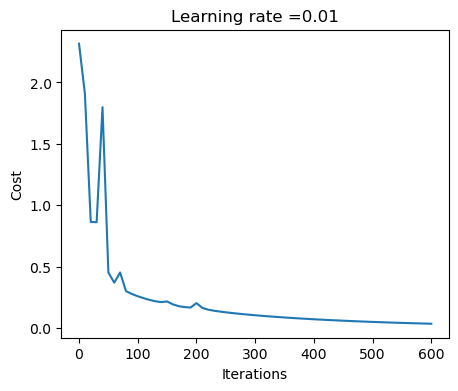

In [19]:
# Example usage
if __name__ == "__main__":
    # Load your training data into X_train and Y_train
    # X_train should have shape (n, m)
    # Y_train should have shape (k, m)

    # Example of generating random data for testing
    np.random.seed(1)
    n = X_train.shape[0]  # Number of input features (e.g., 28*28 for MNIST)
    k = Y_train.shape[0]   # Number of output classes


    # Define the layer sizes
    layer_sizes = [n, 128, 64, k]

    # Train the model
    OFparameters = model(X_train, Y_train, layer_sizes, learning_rate=0.01, num_iterations=601)

In [20]:
import copy
parameters = copy.deepcopy(OFparameters)

Cost after iteration 0: 2.315073052973188  Training accuracy: 14.46% Test accuracy: 15.36% Difference: -0.90
Cost after iteration 100: 0.25636316108389395  Training accuracy: 92.63% Test accuracy: 88.90% Difference: 3.73
Cost after iteration 200: 0.14681827728439936  Training accuracy: 96.03% Test accuracy: 91.40% Difference: 4.63
Cost after iteration 300: 2.0818987397678423  Training accuracy: 33.80% Test accuracy: 33.60% Difference: 0.20
Cost after iteration 400: 0.49199213885330456  Training accuracy: 87.55% Test accuracy: 83.30% Difference: 4.25
Cost after iteration 500: 0.17155020956528397  Training accuracy: 95.09% Test accuracy: 90.32% Difference: 4.77


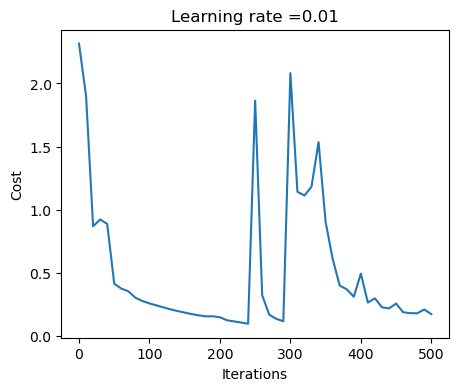

In [21]:
# Example usage
if __name__ == "__main__":
    # Load your training data into X_train and Y_train
    # X_train should have shape (n, m)
    # Y_train should have shape (k, m)

    # Example of generating random data for testing
    np.random.seed(1)
    n = X_train.shape[0]  # Number of input features (e.g., 28*28 for MNIST)
    k = Y_train.shape[0]   # Number of output classes


    # Define the layer sizes
    layer_sizes = [n, 128, 64, k]

    # Train the model
    OFparameters = model2(X_train, Y_train, layer_sizes, parameters_2 = parameters, learning_rate=0.01, num_iterations=501)

In [22]:
def compute_model_distance(parameters_1, parameters_2):
    L = len(parameters_1) // 2  # Number of layers in the neural network
    total_distance = 0

    # Loop through each layer to compute the L2 norm of the difference in weight matrices
    for l in range(1, L + 1):
        W_diff = parameters_1['W' + str(l)] - parameters_2['W' + str(l)]
        total_distance += np.linalg.norm(W_diff) ** 2  # Add the squared norm for each layer

    # Return the total L2 norm across all layers
    return np.sqrt(total_distance)  # Square root to get the final L2 distance

In [23]:
distance = compute_model_distance(OFparameters, parameters)
print(f"Distance between the two models: {distance}")

Distance between the two models: 12.361338667764388


In [24]:
def compute_model_norm(parameters):
    L = len(parameters) // 2  # Number of layers in the neural network
    total_norm = 0

    # Loop through each layer to compute the L2 norm of the weight matrices
    for l in range(1, L + 1):
        W = parameters['W' + str(l)]
        total_norm += np.linalg.norm(W) ** 2  # Add the squared norm for each layer

    # Return the total L2 norm across all layers
    return np.sqrt(total_norm)  # Square root to get the final L2 norm

In [25]:
model_norm = compute_model_norm(OFparameters)
print(f"L2 norm of the model: {model_norm}")

L2 norm of the model: 12.862314975291579


In [26]:
model_norm = compute_model_norm(parameters)
print(f"L2 norm of the model: {model_norm}")

L2 norm of the model: 3.753661675091458


In [27]:
# Count the number of differences
differences = np.sum(predict(X_test, parameters) != predict(X_test, OFparameters))

print(f"Number of test differences: {differences}")

Number of test differences: 366


In [28]:
# Count the number of differences
differences = np.sum(predict(X_train, parameters) != predict(X_train, OFparameters))

print(f"Number of train differences: {differences}")

Number of train differences: 455


In [29]:
#Combine ensembles and predict
def predictEnsemble(X, params1, params2):
    AL1, _ = forward_propagation(X, params1)
    AL2, _ = forward_propagation(X, params2)
    return np.argmax((AL1+AL2)/2, axis=0)

In [30]:
predictionsTr = predictEnsemble(X_train, parameters, OFparameters)
accuracyTr = np.mean(predictionsTr == np.argmax(Y_train, axis=0))
#print(f"Training accuracy: {accuracy * 100:.2f}%")

predictionsTe = predictEnsemble(X_test, parameters, OFparameters)
accuracyTe = np.mean(predictionsTe == np.argmax(Y_test, axis=0))
#print(f"Test accuracy: {accuracy * 100:.2f}%")

print(f" Training accuracy: {accuracyTr * 100:.2f}%", f"Test accuracy: {accuracyTe * 100:.2f}%", f"Difference: {(accuracyTr-accuracyTe)*100:.2f}")

 Training accuracy: 98.49% Test accuracy: 93.02% Difference: 5.47


In [31]:
# Simulating model predictions and ground truth labels
# These should be arrays of shape (5000,) representing your test set
ground_truth = Y_test  # Replace with actual test labels
model1_predictions = predict(X_test, parameters)  # Replace with model 1 predictions
model2_predictions = predict(X_test, OFparameters)  # Replace with model 2 predictions

# Find where model 2 is correct but model 1 is wrong
model1_wrong = model1_predictions != ground_truth
model2_correct = model2_predictions == ground_truth

# We're interested in cases where model 1 is wrong, but model 2 is correct
model2_found_new_correct = np.logical_and(model1_wrong, model2_correct)

# Counting the number of such cases
num_model2_correct_but_model1_wrong = np.sum(model2_found_new_correct)

print(f"Number of test labels where Model 2 is correct but Model 1 is not: {num_model2_correct_but_model1_wrong}")

# Find where model 1 is correct but model 2 is wrong
model1_correct = model1_predictions == ground_truth
model2_wrong = model2_predictions != ground_truth

# We're interested in cases where model 1 is correct, but model 2 is wrong
model1_found_new_correct = np.logical_and(model1_correct, model2_wrong)

# Counting the number of such cases
num_model1_correct_but_model2_wrong = np.sum(model1_found_new_correct)

print(f"Number of test labels where Model 1 is correct but Model 2 is not: {num_model1_correct_but_model2_wrong}")

Number of test labels where Model 2 is correct but Model 1 is not: 183
Number of test labels where Model 1 is correct but Model 2 is not: 143


In [32]:
# Predict on training data
predictions = predict(X_train, OFparameters)
accuracy = np.mean(predictions == np.argmax(Y_train, axis=0))
print(f"Training accuracy: {accuracy * 100:.2f}%")

predictions = predict(X_test, OFparameters)
accuracy = np.mean(predictions == np.argmax(Y_test, axis=0))
print(f"Test accuracy: {accuracy * 100:.2f}%")

Training accuracy: 95.09%
Test accuracy: 90.32%


In [33]:
# Predict on training data
predictions = predict(X_train, parameters)
accuracy = np.mean(predictions == np.argmax(Y_train, axis=0))
print(f"Training accuracy: {accuracy * 100:.2f}%")

predictions = predict(X_test, parameters)
accuracy = np.mean(predictions == np.argmax(Y_test, axis=0))
print(f"Test accuracy: {accuracy * 100:.2f}%")

Training accuracy: 99.43%
Test accuracy: 93.08%


In [34]:
# Predict on training data
predictions = predict(X_train, parameters)
accuracy = np.mean(predictions == np.argmax(Y_train, axis=0))
print(f"Training accuracy: {accuracy * 100:.2f}%")

predictions = predict(X_test, parameters)
accuracy = np.mean(predictions == np.argmax(Y_test, axis=0))
print(f"Test accuracy: {accuracy * 100:.2f}%")

Training accuracy: 99.43%
Test accuracy: 93.08%


In [35]:
################################################################GPT####END###########################################################

In [36]:
print(parameters["W3"])

[[-2.09132480e-03 -4.69666909e-02 -2.93104367e-02  4.15518409e-03
  -3.41441693e-02 -1.39132854e-02  1.28232247e-01 -3.30017817e-03
  -4.45623494e-02  4.60600609e-02  6.34744981e-02 -1.51373693e-02
   5.72376057e-03  8.11976774e-02 -7.76593544e-03  5.04515108e-02
   5.23743813e-02 -4.43723503e-02 -4.26296784e-03 -8.29147638e-03
  -4.97254898e-02 -1.94166908e-03 -5.90395486e-02 -8.24095313e-03
   2.80332919e-03 -8.11146491e-03 -3.22773630e-02 -9.68975378e-03
   7.28034879e-02 -1.42546309e-02 -1.42559327e-02 -1.14475860e-02
   6.17793046e-03 -1.25944919e-02  3.60001736e-02  8.05395936e-03
  -4.95274493e-03  7.14519336e-02 -4.17269045e-02 -1.20091832e-02
  -2.39523666e-02 -2.13217552e-02  1.44944759e-02  2.36865010e-02
   7.26080264e-03 -7.64877474e-03 -3.78876822e-02  4.53812646e-03
  -1.26103285e-02 -6.37679616e-03 -3.90041462e-03  7.86611163e-03
  -1.42849741e-02 -1.60676863e-02 -5.09688183e-02 -1.75174743e-03
  -2.87011291e-02 -2.26180084e-03  3.80886127e-03 -1.93117573e-02
  -1.70232